In [11]:
from structural_geometry_2d import Node, LineMember, Support, StructuralGeometry2D, Member_connection
from structural_geometry_2d.generators import three_hinged_frame
from structural_geometry_2d.visualization import plot_2d

In [12]:
n1 = Node("N1", 0, 0)
n2 = Node("N2", 2, 2)
n3 = Node("N3", 4, 0)

In [13]:
n1

Node(name='N1', x=0.0, y=0.0, z=0.0)

In [14]:
print(n1.to_dict())
print(n2.to_dict())


{'name': 'N1', 'x': 0.0, 'y': 0.0, 'z': 0.0}
{'name': 'N2', 'x': 2.0, 'y': 0.0, 'z': 2.0}


In [15]:
m1 = LineMember("M1", "N1", "N2", "beam")
m2 = LineMember("M2", "N2", "N3", "beam")
print(m1.start_node)
print(m1.end_node)
print(m1.member_type)
print(m1.id)
m1.to_dict()

N1
N2
beam
M1


{'name': 'M1', 'start_node': 'N1', 'end_node': 'N2', 'type': 'beam'}

In [16]:
s1 = Support("S1", "N1", "fixed", "fixed", "fixed", "free", "free", "free")
s2 = Support("S2", "N3", "fixed", "free", "free", "free", "free", "free")
s1.to_dict()

{'name': 'S1',
 'node_name': 'N1',
 'ux': 'fixed',
 'uy': 'fixed',
 'uz': 'fixed',
 'rx': 'free',
 'ry': 'free',
 'rz': 'free'}

In [17]:
h1 = Member_connection("H1", "M1", "end", "rigid", "rigid", "rigid", "free", "free", "free")

In [18]:
sg2d = StructuralGeometry2D()

In [19]:
sg2d.add_node(n1)
sg2d.add_node(n2)
sg2d.add_node(n3)
sg2d.add_member(m1)
sg2d.add_member(m2)
sg2d.add_support(s1)
sg2d.add_support(s2)

In [20]:
sg2d.to_dict()

{'id': 'SG2D',
 'nodes': [{'name': 'N1', 'x': 0.0, 'y': 0.0, 'z': 0.0},
  {'name': 'N2', 'x': 2.0, 'y': 0.0, 'z': 2.0},
  {'name': 'N3', 'x': 4.0, 'y': 0.0, 'z': 0.0}],
 'members': [{'name': 'M1',
   'start_node': 'N1',
   'end_node': 'N2',
   'type': 'beam'},
  {'name': 'M2', 'start_node': 'N2', 'end_node': 'N3', 'type': 'beam'}],
 'supports': [{'name': 'S1',
   'node_name': 'N1',
   'ux': 'fixed',
   'uy': 'fixed',
   'uz': 'fixed',
   'rx': 'free',
   'ry': 'free',
   'rz': 'free'},
  {'name': 'S2',
   'node_name': 'N3',
   'ux': 'fixed',
   'uy': 'free',
   'uz': 'free',
   'rx': 'free',
   'ry': 'free',
   'rz': 'free'}]}

In [21]:
print(sg2d.validate())

None


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x', ylabel='z'>)

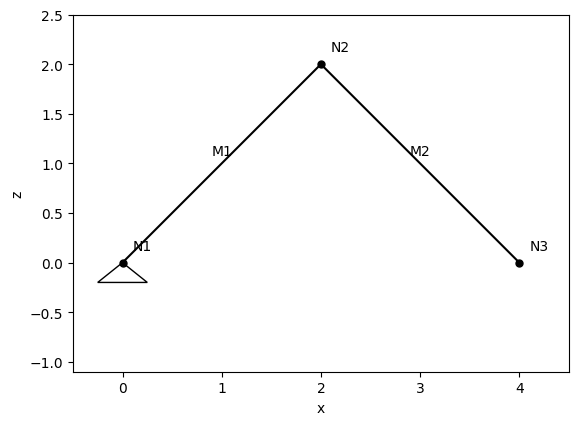

In [22]:
plot_2d.plot_geometry_2d(sg2d, show_node_names=True, show_member_names=True, show_supports=True)

In [23]:
model1 = three_hinged_frame.generate_three_hinged_frame(20, 4, 5, "frame_1")

In [24]:
model1.members

[LineMember(name='M1', start_node='N1', end_node='N2', member_type='column'),
 LineMember(name='M2', start_node='N2', end_node='N3', member_type='rafter'),
 LineMember(name='M3', start_node='N3', end_node='N4', member_type='rafter'),
 LineMember(name='M4', start_node='N4', end_node='N5', member_type='column')]

In [25]:
model1.to_dict()

{'id': 'frame_1',
 'nodes': [{'name': 'N1', 'x': 0.0, 'y': 0.0, 'z': 0.0},
  {'name': 'N2', 'x': 0.0, 'y': 0.0, 'z': 4.0},
  {'name': 'N3', 'x': 10.0, 'y': 0.0, 'z': 5.0},
  {'name': 'N4', 'x': 20.0, 'y': 0.0, 'z': 4.0},
  {'name': 'N5', 'x': 20.0, 'y': 0.0, 'z': 0.0}],
 'members': [{'name': 'M1',
   'start_node': 'N1',
   'end_node': 'N2',
   'type': 'column'},
  {'name': 'M2', 'start_node': 'N2', 'end_node': 'N3', 'type': 'rafter'},
  {'name': 'M3', 'start_node': 'N3', 'end_node': 'N4', 'type': 'rafter'},
  {'name': 'M4', 'start_node': 'N4', 'end_node': 'N5', 'type': 'column'}],
 'supports': [{'name': 'S1',
   'node_name': 'N1',
   'ux': 'fixed',
   'uy': 'fixed',
   'uz': 'fixed',
   'rx': 'free',
   'ry': 'free',
   'rz': 'free'},
  {'name': 'S2',
   'node_name': 'N5',
   'ux': 'free',
   'uy': 'fixed',
   'uz': 'fixed',
   'rx': 'free',
   'ry': 'free',
   'rz': 'free'}]}

In [26]:
model1.to_json()

'{\n  "id": "frame_1",\n  "nodes": [\n    {\n      "name": "N1",\n      "x": 0.0,\n      "y": 0.0,\n      "z": 0.0\n    },\n    {\n      "name": "N2",\n      "x": 0.0,\n      "y": 0.0,\n      "z": 4.0\n    },\n    {\n      "name": "N3",\n      "x": 10.0,\n      "y": 0.0,\n      "z": 5.0\n    },\n    {\n      "name": "N4",\n      "x": 20.0,\n      "y": 0.0,\n      "z": 4.0\n    },\n    {\n      "name": "N5",\n      "x": 20.0,\n      "y": 0.0,\n      "z": 0.0\n    }\n  ],\n  "members": [\n    {\n      "name": "M1",\n      "start_node": "N1",\n      "end_node": "N2",\n      "type": "column"\n    },\n    {\n      "name": "M2",\n      "start_node": "N2",\n      "end_node": "N3",\n      "type": "rafter"\n    },\n    {\n      "name": "M3",\n      "start_node": "N3",\n      "end_node": "N4",\n      "type": "rafter"\n    },\n    {\n      "name": "M4",\n      "start_node": "N4",\n      "end_node": "N5",\n      "type": "column"\n    }\n  ],\n  "supports": [\n    {\n      "name": "S1",\n      "nod

In [27]:
model1.validate()

In [28]:
from structural_geometry_2d import visualization

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x', ylabel='z'>)

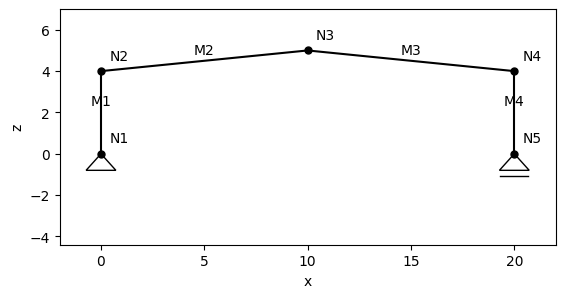

In [29]:
visualization.plot_geometry_2d(model1, show_node_names=True, show_member_names=True, show_supports=True)